<a href="https://colab.research.google.com/github/Davoudasad/ME5920/blob/main/ME5920.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework1
Problem1



Original shape : torch.Size([1000, 1, 28, 28])
Batched shape  : torch.Size([40, 25, 1, 28, 28])


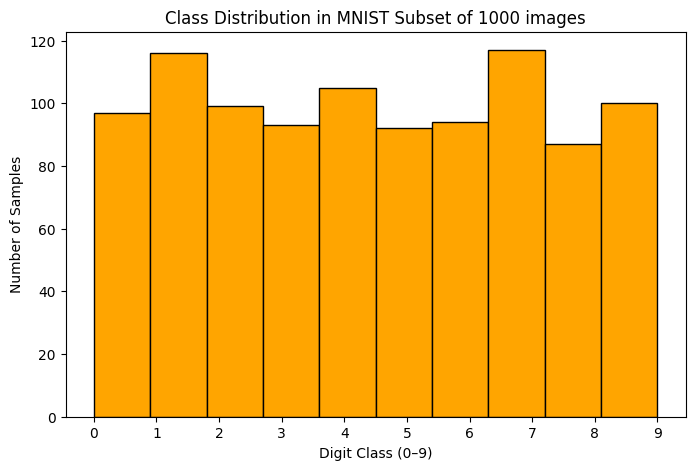

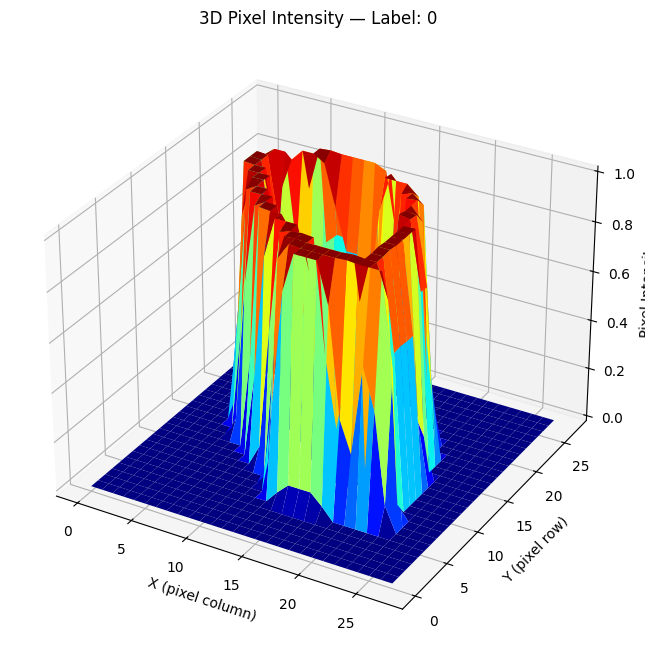

In [ ]:
import torch
import torchvision
from torch.utils.data import Subset
import torchvision.transforms as transforms
from einops import rearrange
import matplotlib.pyplot as plt
import numpy as np
import random

transform =  transforms.ToTensor()
dataset = torchvision.datasets.MNIST(root='./data',
                                     train=True,
                                     download=True,
                                     transform=transform) #Download MNIST
indices = list(range(1000))
subset = Subset(dataset, indices) #Create 1000 sample subset (take the first 1,000 samples)

images = torch.stack([subset[i][0] for i in range(len(subset))]) #Stack all images into a single tensor [1000, 1, 28, 28]
batched = rearrange(images, '(b n) c h w -> b n c h w', n=25)
print(f"Original shape : {images.shape}")
print(f"Batched shape  : {batched.shape}")


idx = random.randint(0, 999) # Randomly select one sample from 1000
image, label = subset[idx]
image_np = image.squeeze().numpy() #Squeez to 2D array [28, 28]
x = np.arange(0, 28)
y = np.arange(0, 28)
x, y = np.meshgrid(x, y)

# Plot histogram of Classes in subset
labels = [subset[i][1] for i in range(len(subset))] # Extract all labels from the subset
plt.figure(figsize=(8, 5))
plt.hist(labels, bins=10, range=(0, 9), edgecolor='black', color='orange')
plt.title('Class Distribution in MNIST Subset of 1000 images')
plt.xlabel('Digit Class (0–9)')
plt.ylabel('Number of Samples')
plt.xticks(range(10))
plt.show()


# Plot in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, image_np, cmap='jet')
ax.set_title(f'3D Pixel Intensity — Label: {label}')
ax.set_xlabel('X (pixel column)')
ax.set_ylabel('Y (pixel row)')
ax.set_zlabel('Pixel Intensity')

plt.show()














Homework1
Problem 2

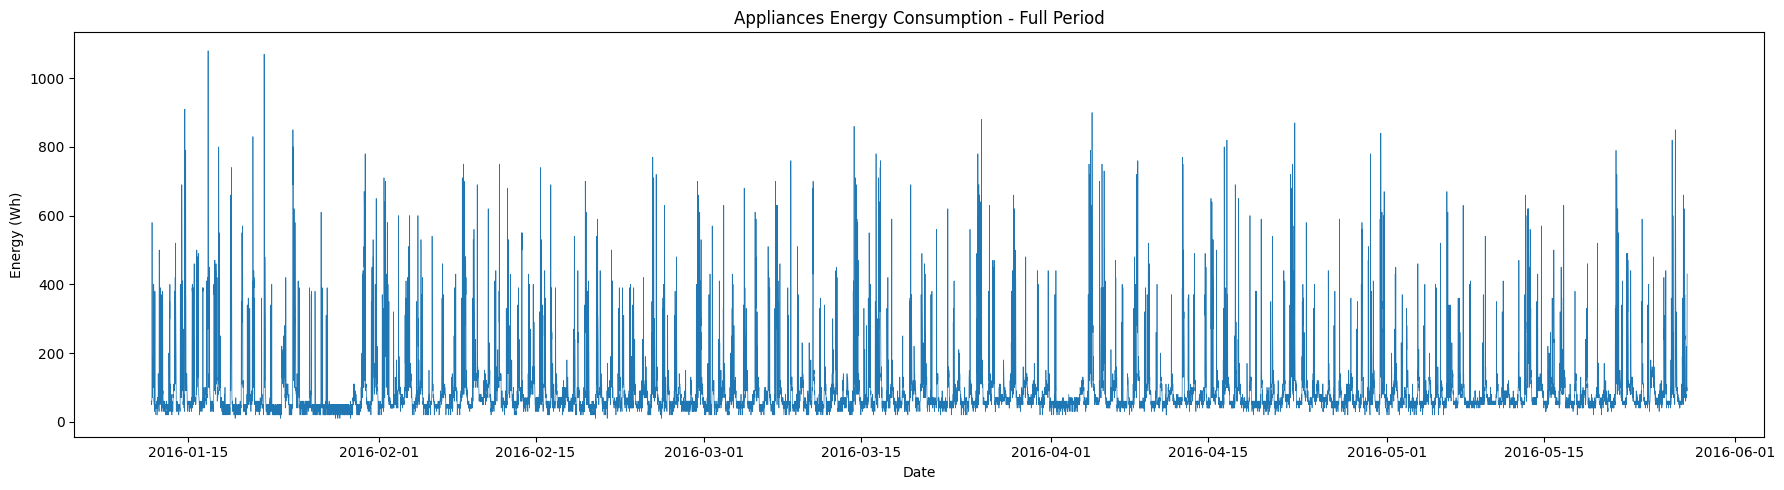

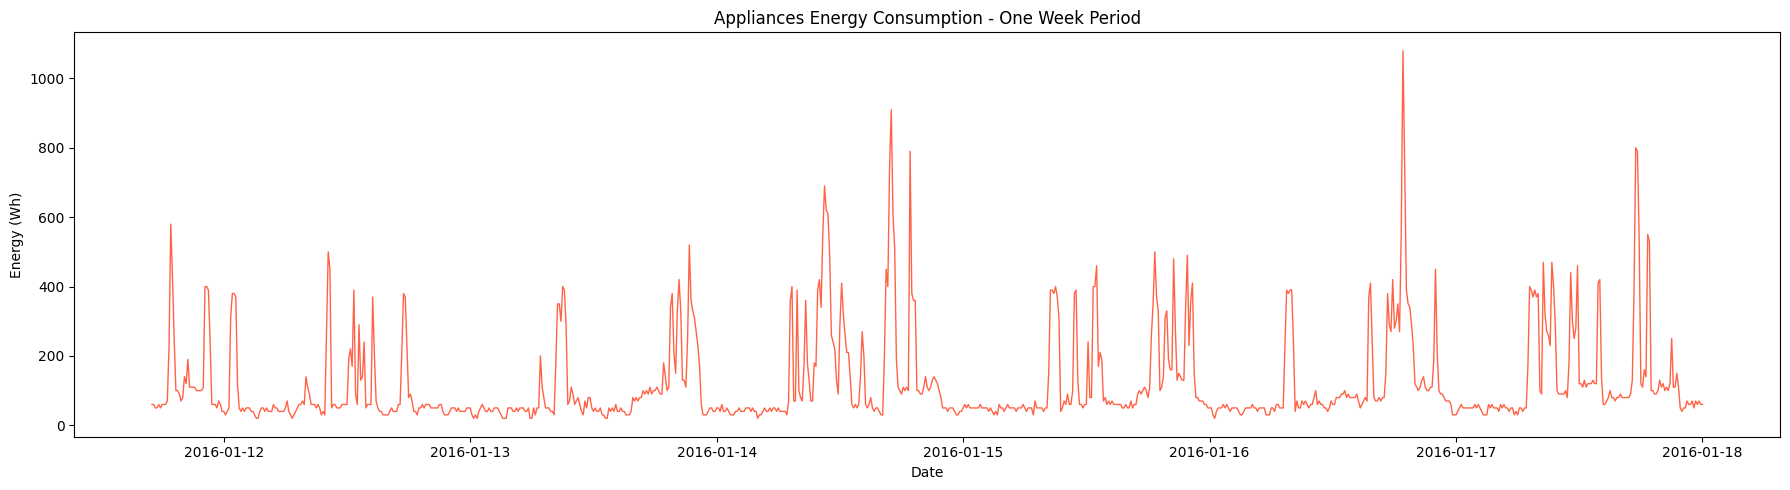

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("energydata_complete.csv", parse_dates=['date'])
#print(df.head())
one_week = df[df['date'].between('2016-01-11', '2016-01-18')]


plt.figure(figsize=(18, 5))
plt.plot(df['date'], df['Appliances'], linewidth=0.5)
plt.title('Appliances Energy Consumption - Full Period')
plt.xlabel('Date')
plt.ylabel('Energy (Wh)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))
plt.plot(one_week['date'], one_week['Appliances'], color='tomato', linewidth=1)
plt.title('Appliances Energy Consumption - One Week Period')
plt.xlabel('Date')
plt.ylabel('Energy (Wh)')
plt.tight_layout()
plt.show()